In [ ]:
# 04_train_rssm_dreamer_world_model.ipynb — Cell 0: Imports + GPU + seeds
import os, glob, json, time, math, pickle, random, hashlib
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

SEED_BASE = 1337

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

DEVICE: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Cell 1: Mount Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 2: Paths + load sequence indices + shard map
DATASET_PATH = "/content/drive/MyDrive/AIAGENT_FINAL/obtain_diamond_v3_fixdone"
SEQ_DIR      = "/content/drive/MyDrive/AIAGENT_FINAL/outputs_sequences"
OUT_ROOT     = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model"
os.makedirs(OUT_ROOT, exist_ok=True)

train_pkl = os.path.join(SEQ_DIR, "train_sequences.pkl")
val_pkl   = os.path.join(SEQ_DIR, "val_sequences.pkl")
test_pkl  = os.path.join(SEQ_DIR, "test_sequences.pkl")
meta_json = os.path.join(SEQ_DIR, "sequences_meta.json")

with open(train_pkl, "rb") as f: train_seqs = pickle.load(f)
with open(val_pkl, "rb") as f:   val_seqs   = pickle.load(f)
with open(test_pkl, "rb") as f:  test_seqs  = pickle.load(f)
with open(meta_json, "r") as f:  seq_meta   = json.load(f)

print("Loaded seq indices:", len(train_seqs), len(val_seqs), len(test_seqs))
SEQ_LEN = int(seq_meta["seq_len"])   # 50
BURN_IN = int(seq_meta["burn_in"])   # 10

# shard map
shards = sorted(glob.glob(os.path.join(DATASET_PATH, "shard_*.npz")))
path_map = {os.path.basename(p): p for p in shards}
assert len(path_map) == 30

def check(seqs, name):
    names = {s["shard"] for s in seqs}
    missing = sorted(list(names - set(path_map.keys())))
    assert len(missing) == 0, f"{name} references missing shards: {missing[:5]}"
check(train_seqs, "train"); check(val_seqs, "val"); check(test_seqs, "test")
print("Shard references OK.")

Loaded seq indices: 200000 150952 149650
Shard references OK.


In [ ]:
# Cell 3: compute train-state normalization stats
train_shard_names = set(seq_meta["splits"]["train_shards"])

sum_x = np.zeros((28,), dtype=np.float64)
sum_x2 = np.zeros((28,), dtype=np.float64)
count = 0

for shard_name in train_shard_names:
    with np.load(path_map[shard_name]) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        state = np.concatenate([obs, mainhand], axis=1)  # (N,28)
    sum_x += state.sum(axis=0)
    sum_x2 += (state ** 2).sum(axis=0)
    count += state.shape[0]

state_mean = (sum_x / count).astype(np.float32)
state_var = (sum_x2 / count) - (sum_x / count) ** 2
state_std = np.sqrt(np.maximum(state_var, 1e-8)).astype(np.float32)

print("state_mean shape:", state_mean.shape)
print("state_std shape:", state_std.shape)
print("min std:", state_std.min(), "max std:", state_std.max())

state_mean shape: (28,)
state_std shape: (28,)
min std: 1e-04 max std: 173.9931


In [ ]:
# Cell 4: Config (Dreamer-style RSSM, adapted to low-dim state observations)
CFG = {
    "model": "RSSM_DreamerStyle_lowdim",
    "state_dim": 28,
    "action_dim": 15,
    "seq_len": SEQ_LEN,
    "burn_in": BURN_IN,

    "deter_dim": 256,
    "stoch_dim": 32,
    "hidden": 256,
    "min_std": 0.1,

    # much safer loss weights for this dataset
    "w_recon": 1.0,
    "w_reward": 0.1,
    "w_cont": 0.1,
    "w_kl": 0.1,

    "kl_free_nats": 0.1,
    "kl_balance": 0.8,

    "use_milestone_bce": True,
    "w_milestone": 0.1,

    "batch_size": 32,
    "num_workers": 0,
    "lr": 3e-4,
    "weight_decay": 1e-6,
    "grad_clip": 100.0,

    "max_steps": 30000,
    "log_every": 50,
    "eval_every": 500,
    "early_stop_patience": 8,

    "val_cap": 10000,
    "test_cap": 20000,

    "rollout_horizons": [1, 2, 5, 10, 20],
}
print(json.dumps(CFG, indent=2))

{
  "model": "RSSM_DreamerStyle_lowdim",
  "state_dim": 28,
  "action_dim": 15,
  "seq_len": 50,
  "burn_in": 10,
  "deter_dim": 256,
  "stoch_dim": 32,
  "hidden": 256,
  "min_std": 0.1,
  "w_recon": 1.0,
  "w_reward": 0.1,
  "w_cont": 0.1,
  "w_kl": 0.1,
  "kl_free_nats": 0.1,
  "kl_balance": 0.8,
  "use_milestone_bce": true,
  "w_milestone": 0.1,
  "batch_size": 32,
  "num_workers": 0,
  "lr": 0.0003,
  "weight_decay": 1e-06,
  "grad_clip": 100.0,
  "max_steps": 30000,
  "log_every": 50,
  "eval_every": 500,
  "early_stop_patience": 8,
  "val_cap": 10000,
  "test_cap": 20000,
  "rollout_horizons": [
    1,
    2,
    5,
    10,
    20
  ]
}


In [ ]:
# Cell 5: replace load_shard_cached with normalized-state version
_SHARD_CACHE = {}

def load_shard_cached(shard_name: str):
    if shard_name in _SHARD_CACHE:
        return _SHARD_CACHE[shard_name]
    p = path_map[shard_name]
    with np.load(p) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)
        reward = d["reward"].astype(np.float32)
        done = d["done"].astype(np.bool_)
    state_raw = np.concatenate([obs, mainhand], axis=1)   # (N,28)
    state = (state_raw - state_mean) / (state_std + 1e-8) # normalize
    _SHARD_CACHE[shard_name] = (state, action, reward, done)
    return _SHARD_CACHE[shard_name]

In [ ]:
# Cell 6: Sequence dataset (returns full sequences)
class SequenceDataset(Dataset):
    """
    Returns:
      s:  (L+1, 28)   float32 states
      a:  (L,   15)   float32 actions
      r:  (L, )       float32 rewards
      cont:(L,)       float32 continuation = 1 - done[t]  (here done is always 0 inside sequences, but keep general)
    """
    def __init__(self, seqs, seq_len=50):
        self.seqs = seqs
        self.L = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        rec = self.seqs[idx]
        shard = rec["shard"]
        t0 = int(rec["t0"])
        L  = int(rec["length"])
        assert L == self.L

        state, action, reward, done = load_shard_cached(shard)

        s = state[t0:t0+L+1]           # (L+1, 28)
        a = action[t0:t0+L]            # (L,   15)
        r = reward[t0:t0+L]            # (L,)
        cont = 1.0 - done[t0:t0+L].astype(np.float32)  # (L,)

        return (
            torch.from_numpy(s),
            torch.from_numpy(a),
            torch.from_numpy(r),
            torch.from_numpy(cont),
        )

def make_loader(seqs, batch_size, shuffle, cap=None, seed=0):
    if cap is not None and len(seqs) > cap:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(seqs), size=cap, replace=False)
        idx = np.sort(idx)
        seqs = [seqs[i] for i in idx]
    ds = SequenceDataset(seqs, seq_len=CFG["seq_len"])
    dl = DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
    return dl

In [ ]:
# Cell 7: RSSM components (Dreamer-style)
def _init_layer(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

class Encoder(nn.Module):
    # low-dim state -> embed
    def __init__(self, state_dim=28, hidden=256, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, embed_dim), nn.ReLU(),
        )
        self.apply(_init_layer)

    def forward(self, s):
        return self.net(s)

class RSSM(nn.Module):
    """
    Dreamer RSSM (continuous stochastic):
      h_t: deterministic GRU state
      z_t: stochastic state (Gaussian, reparam)
    Prior:   p(z_t | h_t) from (h_t)
    Posterior: q(z_t | h_t, embed_t) from (h_t, embed_t)
    Transition (deter update): h_t = GRU(h_{t-1}, [z_{t-1}, a_{t-1}])
    """
    def __init__(self, action_dim=15, deter_dim=256, stoch_dim=32, hidden=256, min_std=0.1):
        super().__init__()
        self.deter_dim = deter_dim
        self.stoch_dim = stoch_dim
        self.min_std = min_std

        self.gru = nn.GRUCell(stoch_dim + action_dim, deter_dim)

        # prior: h_t -> (mu, std)
        self.prior_net = nn.Sequential(
            nn.Linear(deter_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )

        # posterior: [h_t, embed_t] -> (mu, std)
        self.post_net = nn.Sequential(
            nn.Linear(deter_dim + hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2 * stoch_dim),
        )
        self.apply(_init_layer)

    def init_state(self, batch_size):
        h = torch.zeros(batch_size, self.deter_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.stoch_dim, device=DEVICE)
        return h, z

    def _dist(self, params):
        mu, std = torch.chunk(params, 2, dim=-1)
        std = F.softplus(std) + self.min_std
        return mu, std

    def deter_step(self, h, z, a):
        x = torch.cat([z, a], dim=-1)
        h = self.gru(x, h)
        return h

    def prior(self, h):
        params = self.prior_net(h)
        mu, std = self._dist(params)
        return mu, std

    def posterior(self, h, embed):
        # embed expected hidden-sized; use CFG["hidden"] as embed dim
        x = torch.cat([h, embed], dim=-1)
        params = self.post_net(x)
        mu, std = self._dist(params)
        return mu, std

    def sample(self, mu, std):
        eps = torch.randn_like(mu)
        return mu + eps * std

class Decoder(nn.Module):
    # (h,z) -> reconstruct state (28)
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256, state_dim=28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, state_dim),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x)

class RewardHead(nn.Module):
    # (h,z) -> reward regression (log1p) and optional milestone BCE logit
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.base = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.r_out = nn.Linear(hidden, 1)
        self.m_out = nn.Linear(hidden, 1)
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        f = self.base(x)
        r = self.r_out(f).squeeze(-1)
        m = self.m_out(f).squeeze(-1)
        return r, m

class ContHead(nn.Module):
    # (h,z) -> continuation probability (sigmoid)
    def __init__(self, deter_dim=256, stoch_dim=32, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deter_dim + stoch_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.apply(_init_layer)

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        return self.net(x).squeeze(-1)  # logits

In [ ]:
class DreamerWorldModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(
            state_dim=CFG["state_dim"],
            hidden=CFG["hidden"],
            embed_dim=CFG["hidden"],
        )
        self.rssm = RSSM(
            action_dim=CFG["action_dim"],
            deter_dim=CFG["deter_dim"],
            stoch_dim=CFG["stoch_dim"],
            hidden=CFG["hidden"],
            min_std=CFG["min_std"],
        )
        self.dec = Decoder(
            deter_dim=CFG["deter_dim"],
            stoch_dim=CFG["stoch_dim"],
            hidden=CFG["hidden"],
            state_dim=CFG["state_dim"],
        )
        self.rew = RewardHead(
            deter_dim=CFG["deter_dim"],
            stoch_dim=CFG["stoch_dim"],
            hidden=CFG["hidden"],
        )
        self.cont = ContHead(
            deter_dim=CFG["deter_dim"],
            stoch_dim=CFG["stoch_dim"],
            hidden=CFG["hidden"],
        )

    def forward_sequence(self, s, a):
        """
        Input:
          s: (B, L+1, state_dim)
          a: (B, L, action_dim)

        We infer posterior z_t from s_t, then transition with a_t to h_{t+1},
        then decode predicted s_{t+1}.
        """
        B, Lp1, _ = s.shape
        L = Lp1 - 1

        embed = self.enc(s.reshape(B * (L + 1), -1)).reshape(B, L + 1, -1)

        h, z = self.rssm.init_state(B)

        hs_next, zs_next = [], []
        pri_mu, pri_std = [], []
        post_mu, post_std = [], []

        for t in range(L):
            # posterior over z_t from current observation s_t
            mu_q, std_q = self.rssm.posterior(h, embed[:, t, :])
            z = self.rssm.sample(mu_q, std_q)

            # transition to next deterministic state using action a_t
            h_next = self.rssm.deter_step(h, z, a[:, t, :])

            # prior for z_{t+1} from h_{t+1}
            mu_p, std_p = self.rssm.prior(h_next)
            z_next = self.rssm.sample(mu_p, std_p)

            hs_next.append(h_next)
            zs_next.append(z_next)
            pri_mu.append(mu_p)
            pri_std.append(std_p)
            post_mu.append(mu_q)
            post_std.append(std_q)

            h = h_next
            z = z_next

        hs_next = torch.stack(hs_next, dim=1)      # (B,L,D)
        zs_next = torch.stack(zs_next, dim=1)      # (B,L,Z)
        pri_mu = torch.stack(pri_mu, dim=1)
        pri_std = torch.stack(pri_std, dim=1)
        post_mu = torch.stack(post_mu, dim=1)
        post_std = torch.stack(post_std, dim=1)

        s_hat_next = self.dec(
            hs_next.reshape(B * L, -1),
            zs_next.reshape(B * L, -1)
        ).reshape(B, L, -1)

        r_hat, m_logit = self.rew(
            hs_next.reshape(B * L, -1),
            zs_next.reshape(B * L, -1)
        )
        r_hat = r_hat.reshape(B, L)
        m_logit = m_logit.reshape(B, L)

        cont_logit = self.cont(
            hs_next.reshape(B * L, -1),
            zs_next.reshape(B * L, -1)
        ).reshape(B, L)

        return {
            "s_hat_next": s_hat_next,
            "r_hat": r_hat,
            "m_logit": m_logit,
            "cont_logit": cont_logit,
            "pri_mu": pri_mu,
            "pri_std": pri_std,
            "post_mu": post_mu,
            "post_std": post_std,
        }

In [ ]:
# Recreate kl_diag_gauss (must exist before compute_losses)

def kl_diag_gauss(mu_q, std_q, mu_p, std_p):
    """
    KL(q || p) for diagonal Gaussians.
    All tensors shape (..., z_dim)
    Returns tensor shape (...) after keeping latent dim for caller to sum if needed.
    """
    var_q = std_q ** 2
    var_p = std_p ** 2
    return 0.5 * (
        (var_q + (mu_q - mu_p) ** 2) / (var_p + 1e-8)
        - 1.0
        + torch.log((var_p + 1e-8) / (var_q + 1e-8))
    )

In [ ]:
def compute_losses(batch, wm):
    s, a, r, cont = batch
    s = s.to(DEVICE, non_blocking=True)         # (B,L+1,28)
    a = a.to(DEVICE, non_blocking=True)         # (B,L,15)
    r = r.to(DEVICE, non_blocking=True)         # (B,L)
    cont = cont.to(DEVICE, non_blocking=True)   # (B,L)

    out = wm.forward_sequence(s, a)

    # predict next state s[t+1]
    recon = F.mse_loss(out["s_hat_next"], s[:, 1:, :], reduction="none").mean(dim=-1)
    recon_loss = recon.mean()

    r_tgt = torch.log1p(torch.clamp(r, min=0.0))
    reward_loss = F.mse_loss(out["r_hat"], r_tgt)

    if CFG["use_milestone_bce"]:
        m_tgt = (r > 0).float()
        milestone_loss = F.binary_cross_entropy_with_logits(out["m_logit"], m_tgt)
        m_pred = (torch.sigmoid(out["m_logit"]) > 0.5).float()
        milestone_acc = (m_pred == m_tgt).float().mean().item()
    else:
        milestone_loss = torch.tensor(0.0, device=DEVICE)
        milestone_acc = float("nan")

    cont_loss = F.binary_cross_entropy_with_logits(out["cont_logit"], cont)

    mu_q, std_q = out["post_mu"], out["post_std"]
    mu_p, std_p = out["pri_mu"], out["pri_std"]

    alpha = CFG["kl_balance"]
    kl_a = kl_diag_gauss(mu_q, std_q, mu_p.detach(), std_p.detach()).sum(dim=-1)
    kl_b = kl_diag_gauss(mu_q.detach(), std_q.detach(), mu_p, std_p).sum(dim=-1)
    kl_bal = alpha * kl_a + (1.0 - alpha) * kl_b

    kl_free = torch.clamp(kl_bal, min=CFG["kl_free_nats"]).mean()

    total = (
        CFG["w_recon"] * recon_loss
        + CFG["w_reward"] * reward_loss
        + CFG["w_cont"] * cont_loss
        + CFG["w_kl"] * kl_free
        + (CFG["w_milestone"] * milestone_loss if CFG["use_milestone_bce"] else 0.0)
    )

    logs = {
        "loss_total": float(total.item()),
        "loss_recon": float(recon_loss.item()),
        "loss_reward": float(reward_loss.item()),
        "loss_cont": float(cont_loss.item()),
        "loss_kl": float(kl_free.item()),
        "milestone_acc": float(milestone_acc),
    }
    return total, logs

In [ ]:
# Cell 8: Rollout validation (open-loop prior rollouts) to match "compounding error" analysis
@torch.no_grad()
def rollout_validation_mse(wm, seqs, horizons=(1,2,5,10,20), cap=20000, batch_size=64, step_offset=0, seed=0):
    """
    For each sequence, infer posterior at time t=step_offset to get (h,z).
    Then roll forward H steps using PRIOR (no access to future observations), with teacher-forced actions.
    Decode predicted states at horizon H and compare to true state s[t+H].
    """
    wm.eval()
    horizons = sorted(list(horizons))
    Hmax = max(horizons)
    rng = np.random.default_rng(seed)
    if cap is not None and len(seqs) > cap:
        idx = rng.choice(len(seqs), size=cap, replace=False)
        idx = np.sort(idx)
        seqs = [seqs[i] for i in idx]

    # deterministic prefix order after sampling
    ds = SequenceDataset(seqs, seq_len=CFG["seq_len"])
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True, drop_last=False)

    se_sum = {H: 0.0 for H in horizons}
    n = 0

    for s, a, r, cont in tqdm(dl, desc="rollout-val", leave=False):
        s = s.to(DEVICE, non_blocking=True)   # (B,L+1,28)
        a = a.to(DEVICE, non_blocking=True)   # (B,L,15)

        B, Lp1, _ = s.shape
        L = Lp1 - 1
        assert step_offset + Hmax <= L

        # encode obs at step_offset
        emb = wm.enc(s[:, step_offset, :])  # (B,H)

        # init rssm state
        h, z = wm.rssm.init_state(B)

        # warm-up deter state up to step_offset using posterior (teacher forcing on obs)
        # We reconstruct posteriors from t=0..step_offset to land at the correct h for step_offset.
        # This is closer to Dreamer filtering.
        if step_offset > 0:
            emb_all = wm.enc(s[:, :step_offset, :].reshape(B*step_offset, -1)).reshape(B, step_offset, -1)
            for t in range(step_offset):
                mu_q, std_q = wm.rssm.posterior(h, emb_all[:, t, :])
                z = wm.rssm.sample(mu_q, std_q)
                h = wm.rssm.deter_step(h, z, a[:, t, :])

        # posterior at step_offset to set z (conditioned on obs_t)
        mu_q, std_q = wm.rssm.posterior(h, emb)
        z = wm.rssm.sample(mu_q, std_q)

        # open-loop rollout using PRIOR only
        preds = []
        h_t, z_t = h, z
        for k in range(1, Hmax+1):
            # advance deter with action at step_offset + (k-1)
            a_km1 = a[:, step_offset + (k-1), :]
            h_t = wm.rssm.deter_step(h_t, z_t, a_km1)

            # prior sample z_k
            mu_p, std_p = wm.rssm.prior(h_t)
            z_t = wm.rssm.sample(mu_p, std_p)

            # decode predicted state at this horizon
            s_hat = wm.dec(h_t, z_t)
            preds.append(s_hat)

        # preds[k-1] corresponds to horizon k
        for H in horizons:
            sH_pred = preds[H-1]
            sH_true = s[:, step_offset + H, :]
            mse_per = ((sH_pred - sH_true) ** 2).mean(dim=1)
            se_sum[H] += mse_per.sum().item()

        n += B

    return {H: se_sum[H] / max(n, 1) for H in horizons}, n

In [ ]:
@torch.no_grad()
def one_step_validation_mse(wm, seqs, cap=10000, batch_size=64, seed=0):
    wm.eval()
    rng = np.random.default_rng(seed)
    if cap is not None and len(seqs) > cap:
        idx = rng.choice(len(seqs), size=cap, replace=False)
        idx = np.sort(idx)
        seqs = [seqs[i] for i in idx]

    ds = SequenceDataset(seqs, seq_len=CFG["seq_len"])
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True, drop_last=False)

    total = 0.0
    n = 0
    for s, a, r, cont in dl:
        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)
        out = wm.forward_sequence(s, a)
        mse = ((out["s_hat_next"] - s[:, 1:, :]) ** 2).mean(dim=(1,2))
        total += mse.sum().item()
        n += s.size(0)

    return total / max(n, 1)

In [ ]:
# Cell 9: Train loop (budgeted steps + early stopping + checkpointing)
def train_one_seed(seed: int):
    set_seed(seed)

    run_dir = os.path.join(OUT_ROOT, f"seed_{seed}")
    os.makedirs(run_dir, exist_ok=True)

    config_path = os.path.join(run_dir, "config.json")
    log_path    = os.path.join(run_dir, "train_log.json")
    ckpt_path   = os.path.join(run_dir, "checkpoint.pt")

    with open(config_path, "w") as f:
        json.dump({"seed": seed, **CFG, "seq_meta": seq_meta}, f, indent=2)

    wm = DreamerWorldModel().to(DEVICE)
    opt = torch.optim.AdamW(wm.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

    train_dl = make_loader(train_seqs, batch_size=CFG["batch_size"], shuffle=True, cap=None, seed=seed)
    it = iter(train_dl)

    log = {
        "seed": seed,
        "train_steps": [],
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
        "train_reward": [],
        "train_cont": [],
        "milestone_acc": [],

        "val_steps": [],
        "val_rollout": [],  # dict per eval
        "best_val_metric": None,
        "best_step": None,
        "stopped_early": False,
        "time_sec": None,
    }

    best = float("inf")
    best_step = -1
    bad = 0
    t0 = time.time()

    running = {"loss_total":0.0,"loss_recon":0.0,"loss_kl":0.0,"loss_reward":0.0,"loss_cont":0.0,"milestone_acc":0.0}
    running_n = 0

    pbar = tqdm(range(1, CFG["max_steps"]+1), desc=f"rssm-train(seed={seed})", leave=True)
    for step in pbar:
        try:
            batch = next(it)
        except StopIteration:
            it = iter(train_dl)
            batch = next(it)

        wm.train()
        loss, logs = compute_losses(batch, wm)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        if CFG["grad_clip"] is not None:
            nn.utils.clip_grad_norm_(wm.parameters(), CFG["grad_clip"])
        opt.step()

        for k in running:
            running[k] += float(logs[k])
        running_n += 1

        if step % CFG["log_every"] == 0:
            avg = {k: running[k]/max(running_n,1) for k in running}
            running = {k: 0.0 for k in running}
            running_n = 0

            log["train_steps"].append(step)
            log["train_loss"].append(avg["loss_total"])
            log["train_recon"].append(avg["loss_recon"])
            log["train_kl"].append(avg["loss_kl"])
            log["train_reward"].append(avg["loss_reward"])
            log["train_cont"].append(avg["loss_cont"])
            log["milestone_acc"].append(avg["milestone_acc"])

            pbar.set_postfix({
                "loss": f"{avg['loss_total']:.3f}",
                "recon": f"{avg['loss_recon']:.3f}",
                "kl": f"{avg['loss_kl']:.3f}",
                "m_acc": f"{avg['milestone_acc']:.2f}",
            })

        if step % CFG["eval_every"] == 0 or step == CFG["max_steps"]:
            wm.eval()

            val_one = one_step_validation_mse(
                wm,
                val_seqs,
                cap=CFG["val_cap"],
                batch_size=64,
                seed=seed + 111,
            )

            roll, n_eval = rollout_validation_mse(
                wm,
                val_seqs,
                horizons=tuple(CFG["rollout_horizons"]),
                cap=CFG["val_cap"],
                batch_size=64,
                step_offset=0,
                seed=seed + 999,
            )

            # primary early-stopping metric: one-step next-state MSE
            val_metric = float(val_one)

            log["val_steps"].append(step)
            log["val_rollout"].append({
                "n": int(n_eval),
                "one_step_mse": float(val_one),
                "rollout_mse": {str(k): float(v) for k, v in roll.items()},
                "metric": float(val_metric),
            })

            improved = (best - val_metric) > 1e-5
            if improved:
                best = val_metric
                best_step = step
                bad = 0
                torch.save({
                    "state_dict": wm.state_dict(),
                    "cfg": CFG,
                    "seq_meta": seq_meta,
                    "seed": seed,
                    "best_val_metric": best,
                    "best_step": best_step,
                    "val_one_step_mse": float(val_one),
                    "val_rollout": roll,
                }, ckpt_path)
            else:
                bad += 1

            log["best_val_metric"] = float(best)
            log["best_step"] = int(best_step)

            with open(log_path, "w") as f:
                json.dump(log, f, indent=2)

            if bad >= CFG["early_stop_patience"]:
                log["stopped_early"] = True
                break

    log["time_sec"] = float(time.time() - t0)
    with open(log_path, "w") as f:
        json.dump(log, f, indent=2)

    print("Finished seed", seed, "best_val_metric", best, "best_step", best_step, "ckpt", ckpt_path)
    return ckpt_path, log

In [ ]:
# Cell 10: Train remaining seeds (after seed_1337 finishes cleanly)
seeds = [SEED_BASE, SEED_BASE+1, SEED_BASE+2]
ckpts, logs = [], []
for s in seeds:
    ckpt, lg = train_one_seed(s)
    ckpts.append(ckpt)
    logs.append(lg)
print("Checkpoints:", ckpts)

rssm-train(seed=1337):   0%|          | 0/30000 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

...

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/157 [00:00<?, ?it/s]

Finished seed 1339 best_val_metric 0.2880807682365179 best_step 14000 ckpt /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model/seed_1339/checkpoint.pt
Checkpoints: ['/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model/seed_1337/checkpoint.pt', '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model/seed_1338/checkpoint.pt', '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model/seed_1339/checkpoint.pt']


In [ ]:
# Cell 11: Load checkpoints + final TEST rollout evaluation (Dreamer-style open-loop)
@torch.no_grad()
def one_step_test_mse(wm, seqs, cap=20000, batch_size=64, seed=0):
    return one_step_validation_mse(wm, seqs, cap=cap, batch_size=batch_size, seed=seed)


@torch.no_grad()
def load_wm(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    wm = DreamerWorldModel().to(DEVICE)
    wm.load_state_dict(ckpt["state_dict"])
    wm.eval()
    return wm, ckpt

test_rollouts = []
for ckpt_path in ckpts:
    wm, ckpt = load_wm(ckpt_path)

    one_step = one_step_test_mse(
        wm,
        test_seqs,
        cap=CFG["test_cap"],
        batch_size=64,
        seed=int(ckpt["seed"]) + 7,
    )

    roll, n_eval = rollout_validation_mse(
        wm,
        test_seqs,
        horizons=tuple(CFG["rollout_horizons"]),
        cap=CFG["test_cap"],
        batch_size=64,
        step_offset=0,
        seed=int(ckpt["seed"]) + 2024,
    )

    metric = float(np.mean(list(roll.values())))
    test_rollouts.append({
        "seed": int(ckpt["seed"]),
        "best_step": int(ckpt["best_step"]),
        "best_val_metric": float(ckpt["best_val_metric"]),
        "test_one_step_mse": float(one_step),
        "test_rollout_mse": {str(k): float(v) for k,v in roll.items()},
        "test_metric": metric,
        "n_test_sequences": int(n_eval),
        "ckpt": ckpt_path,
    })

for r in test_rollouts:
    print(r["seed"], r["test_rollout_mse"], "metric", r["test_metric"])

out_path = os.path.join(OUT_ROOT, "test_rollout_summary.json")
with open(out_path, "w") as f:
    json.dump(test_rollouts, f, indent=2)
print("Wrote:", out_path)

rollout-val:   0%|          | 0/313 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/313 [00:00<?, ?it/s]

rollout-val:   0%|          | 0/313 [00:00<?, ?it/s]

1337 {'1': 0.569038421356678, '2': 0.5733866639971733, '5': 0.5800227225422859, '10': 0.5832195546030998, '20': 0.5884747995853424} metric 0.578828432416916
1338 {'1': 0.6360287419080735, '2': 0.656705606341362, '5': 0.7085663012266159, '10': 0.7237941999912262, '20': 0.7340328773260116} metric 0.6918255453586578
1339 {'1': 0.44046702288389206, '2': 0.4285578932747245, '5': 0.4302057761102915, '10': 0.4364983237579465, '20': 0.4478089525178075} metric 0.4367075937089324
Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model/test_rollout_summary.json


In [ ]:
def mean_std(xs):
    xs = np.array(xs, dtype=np.float64)
    return float(xs.mean()), float(xs.std(ddof=1)) if len(xs) > 1 else 0.0

rssm_summary = {
    "model": "RSSM_DreamerStyle_lowdim",
    "cfg": CFG,
    "seeds": [int(r["seed"]) for r in test_rollouts],
    "per_seed": test_rollouts,
}

one_step_vals = [r["test_one_step_mse"] for r in test_rollouts]
rssm_summary["test_one_step_mse_mean"], rssm_summary["test_one_step_mse_std"] = mean_std(one_step_vals)

Hs = [int(h) for h in CFG["rollout_horizons"]]
rssm_summary["rollout_mse_mean"] = {}
rssm_summary["rollout_mse_std"] = {}

for H in Hs:
    vals = [r["test_rollout_mse"][str(H)] for r in test_rollouts]
    m, s = mean_std(vals)
    rssm_summary["rollout_mse_mean"][str(H)] = m
    rssm_summary["rollout_mse_std"][str(H)] = s

summary_path = os.path.join(OUT_ROOT, "summary.json")
with open(summary_path, "w") as f:
    json.dump(rssm_summary, f, indent=2)

print("Wrote:", summary_path)
print("One-step test MSE mean/std:",
      rssm_summary["test_one_step_mse_mean"],
      rssm_summary["test_one_step_mse_std"])

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/rssm_world_model/summary.json
One-step test MSE mean/std: 0.5132551239172618 0.07360510003628082


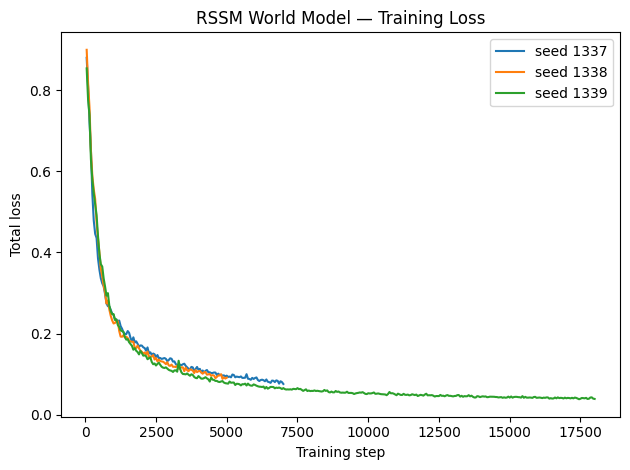

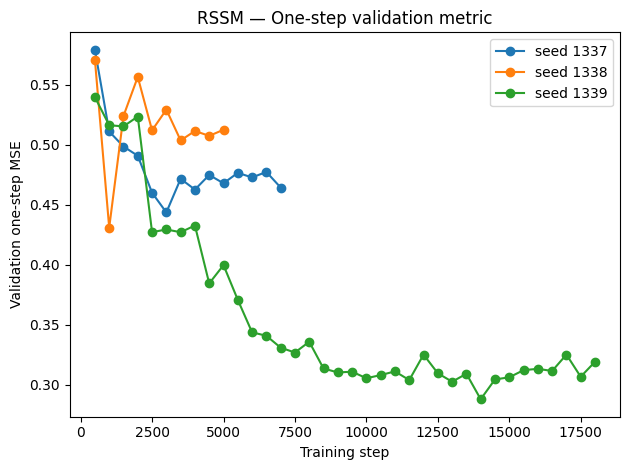

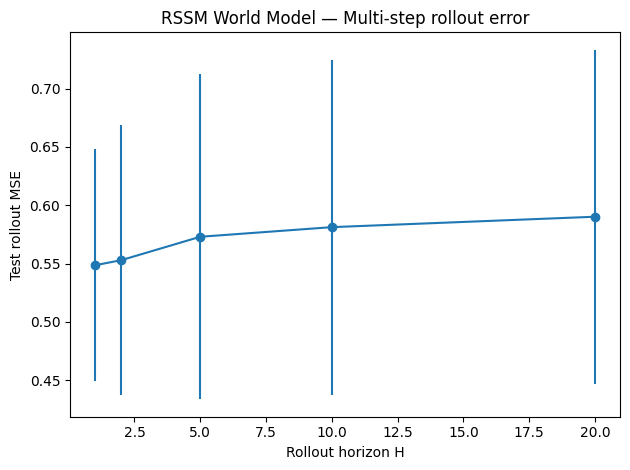

In [ ]:
# Cell 12: Plot training curves + rollout curves vs baseline MLP
import matplotlib.pyplot as plt
import numpy as np

# Training total loss
plt.figure()
for lg in logs:
    plt.plot(lg["train_steps"], lg["train_loss"], label=f"seed {lg['seed']}")
plt.xlabel("Training step"); plt.ylabel("Total loss"); plt.title("RSSM World Model — Training Loss")
plt.legend(); plt.tight_layout(); plt.show()

# Validation rollout metric
plt.figure()
for lg in logs:
    vals = [x["metric"] for x in lg["val_rollout"]]
    plt.plot(lg["val_steps"], vals, marker="o", label=f"seed {lg['seed']}")
plt.xlabel("Training step")
plt.ylabel("Validation one-step MSE")
plt.title("RSSM — One-step validation metric")
plt.legend(); plt.tight_layout(); plt.show()

# Test rollout curve mean±std
Hs = [int(h) for h in CFG["rollout_horizons"]]
vals = np.array([[r["test_rollout_mse"][str(H)] for H in Hs] for r in test_rollouts], dtype=np.float64)
mean = vals.mean(axis=0)
std  = vals.std(axis=0, ddof=1) if vals.shape[0] > 1 else np.zeros_like(mean)

plt.figure()
plt.errorbar(Hs, mean, yerr=std, marker="o")
plt.xlabel("Rollout horizon H")
plt.ylabel("Test rollout MSE")
plt.title("RSSM World Model — Multi-step rollout error")
plt.tight_layout()
plt.show()